# importing libararies

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge,Lasso
from sklearn.svm import SVR
import xgboost as xgb
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.model_selection import GridSearchCV

#Importing Data

In [42]:
data=pd.read_csv('/content/insurance.csv')
df=pd.DataFrame(data)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Data Cleaning

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [44]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [45]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [46]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [47]:
df.drop_duplicates(inplace=True)

In [48]:
for i in df.columns :
  if df[i].dtype == 'object':
    print(df[i].value_counts())
    print("-------------------------------------")


sex
male      675
female    662
Name: count, dtype: int64
-------------------------------------
smoker
no     1063
yes     274
Name: count, dtype: int64
-------------------------------------
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64
-------------------------------------


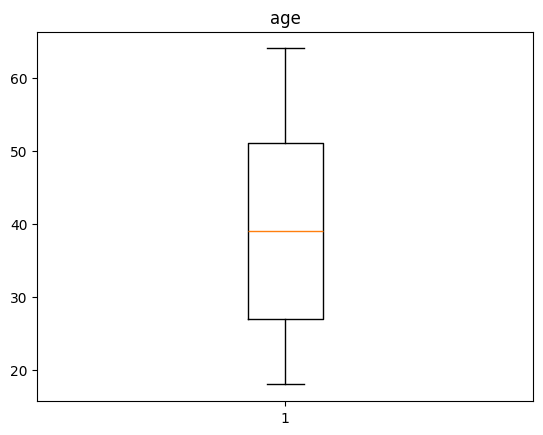

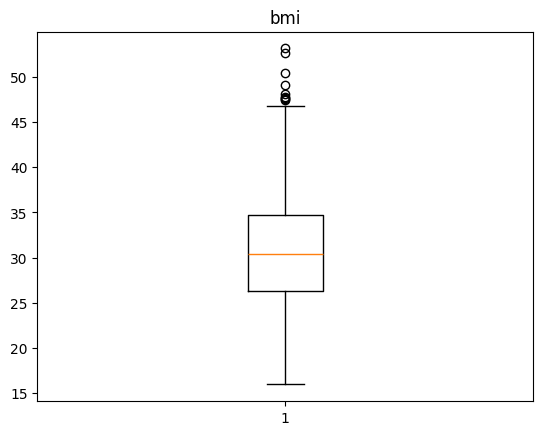

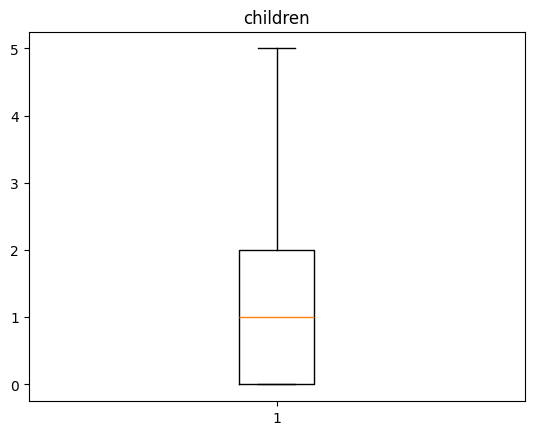

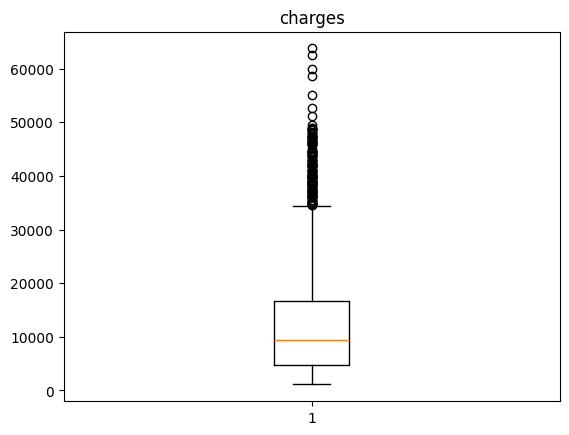

In [49]:
for i in df.columns:

    if df[i].dtype != 'object':  # Check if the column is not of object type
        plt.figure()
        plt.title(i)
        plt.boxplot(df[i])
        plt.show()

# Feature Engineering

In [50]:
num_features=df.select_dtypes(include=['int64','float64'])
cat_features=df.select_dtypes(include=['object'])

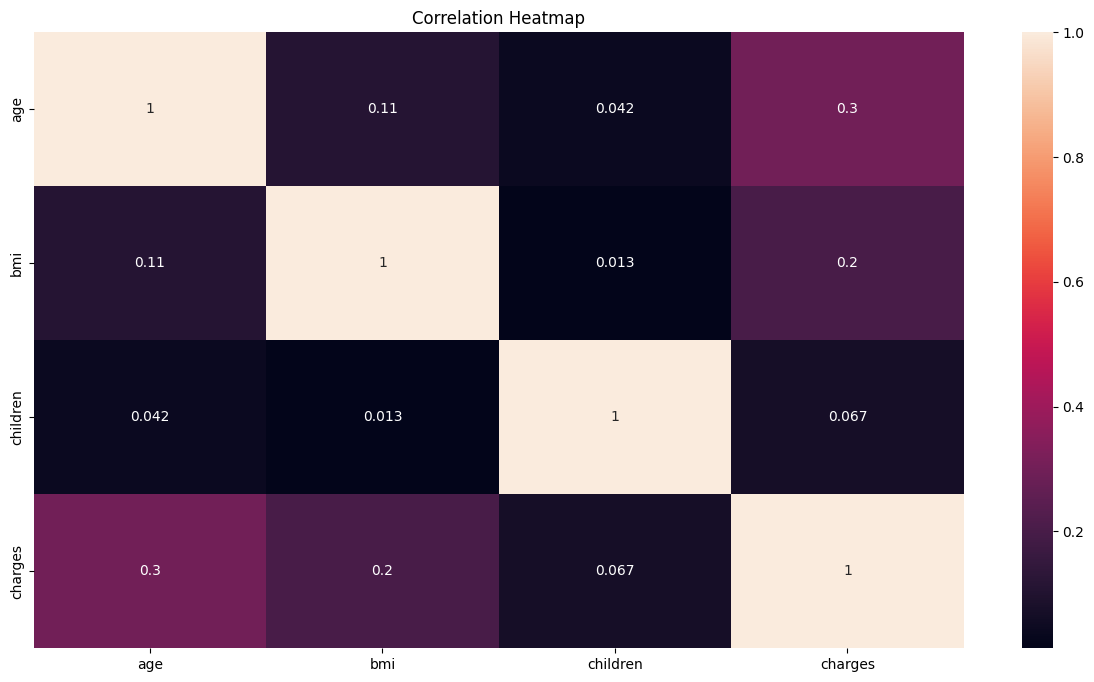

In [51]:
corr = num_features.corr()  # Exclude non-numerical columns
plt.figure(figsize=(15, 8))
sns.heatmap(corr,annot=True)
plt.title('Correlation Heatmap')
plt.show()

In [52]:
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})
df['sex'] = df['sex'].map({'female': 0, 'male': 1})
x=df.drop('charges',axis=1)
y=df['charges']

In [53]:
num_Xfeatures=x.select_dtypes(include=['int64','float64'])
cat_Xfeatures=x.select_dtypes(include=['object'])
mi = mutual_info_regression(num_Xfeatures, y, discrete_features='auto')
mi_series = pd.Series(mi, index=num_Xfeatures.columns)
mi_series.sort_values(ascending=False, inplace=True)
print(mi_series)

age         1.500274
smoker      0.369276
sex         0.176281
children    0.160444
bmi         0.073235
dtype: float64


In [54]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [55]:
# Feature groups
##binary_features = ['sex', 'smoker']
cat_features = ['region']
num_features = ['age', 'bmi', 'children','sex','smoker']  # only continuous vars

preprocessor = ColumnTransformer([
  ## ("Binary", "passthrough", binary_features),  # do NOT scale these
    ("Categorical", OneHotEncoder(drop='first'), cat_features),
    ("Numeric", StandardScaler(), num_features)
])

In [56]:
x_train_scaled=preprocessor.fit_transform(x_train)
x_test_scaled=preprocessor.transform(x_test)

# Model Training

In [57]:
models={
    "LinearRegressor":LinearRegression(),
    "RandomForestRegressor":RandomForestRegressor(),
    "DecisionTreeRegressor":DecisionTreeRegressor(),
    "KNeighborsRegressor":KNeighborsRegressor(),
    "Ridge":Ridge(),
    "Lasso":Lasso(),
    "SVR":SVR(),
    "GradientBoostingRegressor":GradientBoostingRegressor(),
    "XGBRegressor":xgb.XGBRegressor()
}


for i in range (len(list(models))):
  model=list(models.values())[i]
  model.fit(x_train_scaled,y_train)
  y_pred=model.predict(x_test_scaled)

  mae=mean_absolute_error(y_test,y_pred)
  mse=mean_squared_error(y_test,y_pred)
  r2=r2_score(y_test,y_pred)
  print(list(models.keys())[i])
  print("mae",mae)
  print("mse",mse)
  print("r2",r2)
  print("------------------------------------------------")

LinearRegressor
mae 4396.031406695099
mse 41546216.6608684
r2 0.7530385567240127
------------------------------------------------
RandomForestRegressor
mae 2980.40489629383
mse 27072342.557102315
r2 0.8390750030179962
------------------------------------------------
DecisionTreeRegressor
mae 3446.3740827238807
mse 48080225.47085261
r2 0.7141987206141802
------------------------------------------------
KNeighborsRegressor
mae 3478.814147328358
mse 31306504.726672046
r2 0.8139060493922758
------------------------------------------------
Ridge
mae 4397.697481128323
mse 41556139.61375027
r2 0.7529795721289706
------------------------------------------------
Lasso
mae 4395.934313158375
mse 41547328.1893894
r2 0.7530319495113744
------------------------------------------------
SVR
mae 9180.840002963005
mse 188215773.45626542
r2 -0.11880317381212091
------------------------------------------------
GradientBoostingRegressor
mae 2792.156833544312
mse 25413333.238161143
r2 0.8489365829341267
---

# Hyperparameter Tuning For KNN

In [58]:
knn=KNeighborsRegressor()
knn_params={
    'n_neighbors':range(1,20),
    'weights':['uniform','distance'],
    'algorithm':['auto','ball_tree','kd_tree','brute']
}
knn_params

{'n_neighbors': range(1, 20),
 'weights': ['uniform', 'distance'],
 'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']}

In [59]:
grid= GridSearchCV(knn,knn_params,cv=5, scoring='r2', n_jobs=-1)
grid.fit(x_train_scaled,y_train)

print("Best params:", grid.best_params_)
print("Best R²:", grid.best_score_)

pred=grid.predict(x_test_scaled)
mse=mean_squared_error(y_test,pred)
mae=mean_absolute_error(y_test,pred)
print('mse :',mse)
print('mae :',mae)
print('r2 score:',r2_score(y_test,pred))
#

Best params: {'algorithm': 'auto', 'n_neighbors': 14, 'weights': 'uniform'}
Best R²: 0.8140934469650034
mse : 30468109.077228233
mae : 3470.0473406092747
r2 score: 0.8188896896912966
